In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.colors as mplcolors
import matplotlib.ticker as ptick
import matplotlib.colorbar as mplcolorbar
import matplotlib.cm as mplcm
from matplotlib.ticker import AutoMinorLocator
import math
import Leadangle_wave as Wave
from Leadangle_fit_JunoUVS import eqwlong_err
from Leadangle_fit_JunoUVS import TEB_transit
from Leadangle_fit_JunoUVS import create_argmesh
from column_mass import calc as column_calc
from UniversalColor import UniversalColor
from SharedX import ShareXaxis
from legend_shadow import legend_shadow

import JupiterMag as jm

jm.Internal.Config(Model='jrm33', CartesianIn=True, CartesianOut=True)
jm.Con2020.Config(equation_type='analytic')

UC = UniversalColor()
UC.set_palette()

F = ShareXaxis()
F.fontsize = 20
F.fontname = 'Liberation Sans Narrow'
F.set_default()

# F.set_figparams()
# F.initialize()

Importing Library
done


In [2]:
exname = '1001/20260421_026'
TARGET_MOON = 'Ganymede'
target_fp = ['MAW', 'TEB']
PJ_num = ['23']
Ai_num = 3
ni_num = 150
Ti_num = 1
Zi = 1.3                # Io: 1.3 / Eu: 1.4 / Ga: 1.3
Te = 300.0              # Io: 6.0 [eV]/ Eu: 20.0 / Ga: 300.0


chi2_1d = np.loadtxt('results/fit/'+exname+'/params_chi2.txt')
Ai_1d = np.loadtxt('results/fit/'+exname+'/params_Ai.txt')
ni_1d = np.loadtxt('results/fit/'+exname+'/params_ni.txt')
Ti_1d = np.loadtxt('results/fit/'+exname+'/params_Ti.txt')
H_1d = np.loadtxt('results/fit/'+exname+'/params_H.txt')
eqlead_est = np.loadtxt('results/fit/'+exname+'/eqlead_est.txt')
eqlead_obs = np.loadtxt('results/fit/'+exname+'/eqlead_obs.txt')
sigma_total = np.loadtxt('results/fit/'+exname+'/sigma_y.txt')
hem_obs = np.loadtxt('results/fit/'+exname+'/hems_obs.txt')
moon_S3wlon_obs = np.loadtxt('results/fit/'+exname+'/moon_S3wlon_obs.txt')
print('chi2_1d.shape:', chi2_1d.shape)
print('eqlead_est.shape:', eqlead_est.shape)

chi2_3d = chi2_1d.reshape(ni_num, Ai_num, Ti_num)
H_3d = H_1d.reshape(ni_num, Ai_num, Ti_num)
Ai_3d = Ai_1d.reshape(ni_num, Ai_num, Ti_num)
ni_3d = ni_1d.reshape(ni_num, Ai_num, Ti_num)
Ti_3d = Ti_1d.reshape(ni_num, Ai_num, Ti_num)
H_3d = H_1d.reshape(ni_num, Ai_num, Ti_num)
eqlead_est_3d = eqlead_est[1].reshape(ni_num, Ai_num, Ti_num)

# 保存されているカイ2乗値は自由度で割ってしまっているので
# ここで元に戻す
chi2_3d = chi2_3d*(eqlead_est.shape[0]-3)

sigma_obs = sigma_total

print('Parameter ranges:')
print('--- Ai:', np.min(Ai_3d), np.max(Ai_3d))
print('--- ni:', np.min(ni_3d), np.max(ni_3d))
print('--- Ti:', np.min(Ti_3d), np.max(Ti_3d))
print('--- Hi:', np.min(H_3d)/71492E+3, np.max(H_3d)/71492E+3)
print('Degree of freedom:', (eqlead_est.shape[0]-3))

chi2_1d.shape: (450,)
eqlead_est.shape: (11, 450)
Parameter ranges:
--- Ai: 12.0 16.0
--- ni: 1.0 99.99999999999994
--- Ti: 1.0 1.0
--- Hi: 3.16379518932563 3.6532360084359907
Degree of freedom: 8


In [3]:
# %% Constants
dchi_1s = 2.30     # デルタchi2の1シグマ区間
dchi_2s = 6.17     # デルタchi2の2シグマ区間
dchi_3s = 11.8     # デルタchi2の3シグマ区間

MU0 = 1.26E-6            # 真空中の透磁率
AMU2KG = 1.66E-27        # 原子質量をkgに変換するファクタ [kg]
RJ = 71492E+3            # JUPITER RADIUS [m]
MJ = 1.90E+27            # JUPITER MASS [kg]
C = 2.99792E+8           # LIGHT SPEED [m/s]
G = 6.67E-11             # 万有引力定数  [m^3 kg^-1 s^-2]

Psyn_io = (12.89)*3600      # Moon's synodic period [sec]
Psyn_eu = (11.22)*3600      # Moon's synodic period [sec]
Psyn_ga = (10.53)*3600      # Moon's synodic period [sec]

if TARGET_MOON == 'Io':
    Psyn = Psyn_io
    r_moon = 5.9*RJ
    xticks = np.array([1, 10, 100, 500, 1000, 5000])
elif TARGET_MOON == 'Europa':
    Psyn = Psyn_eu
    r_moon = 9.4*RJ
    xticks = np.array([1, 10, 100, 500, 1000, 5000])
elif TARGET_MOON == 'Ganymede':
    Psyn = Psyn_ga
    r_moon = 15.0*RJ
    xticks = np.array([1, 10, 100, 1000])

sigma_x = eqwlong_err(Psyn, dt=22.5)*np.ones(sigma_obs.shape)
print('sigma_x [deg]:', sigma_x)

sigma_x [deg]: [0.21367521 0.21367521 0.21367521 0.21367521 0.21367521 0.21367521
 0.21367521 0.21367521 0.21367521 0.21367521 0.21367521]


In [4]:
# %% GANYMEDE ONLY === read the current constant
def read_current_coef():
    f0 = np.loadtxt('results/azimuthal_current_fit/' +
                    TARGET_MOON[0:2]+'_coef_0.txt')
    f1 = np.loadtxt('results/azimuthal_current_fit/' +
                    TARGET_MOON[0:2]+'_coef_1.txt')

    con20_pj_idx = np.array([1, 3, 4, 5, 6,
                             7, 8, 9, 10, 11,
                             12, 13, 14, 15, 16,
                             17, 18, 19, 20, 21,
                             22, 23, 24])

    select_pj = np.where(con20_pj_idx == PJ_num[0])

    return f0[select_pj], f1[select_pj]


# %% GANYMEDE ONLY === read the magnetodisk thickness coefficient
def read_disk_thick_coef():
    f0 = np.loadtxt('results/magdisk_thickness_fit/' +
                    TARGET_MOON[0:2]+'_coef_0.txt')
    f1 = np.loadtxt('results/magdisk_thickness_fit/' +
                    TARGET_MOON[0:2]+'_coef_1.txt')
    con20_pj_idx = np.array([1, 3, 4, 5, 6,
                             7, 8, 9, 10, 11,
                             12, 13, 14, 15, 16,
                             17, 18, 19, 20, 21,
                             22, 23, 24])

    select_pj = np.where(con20_pj_idx == PJ_num[0])
    return f0[select_pj], f1[select_pj]

In [5]:
print(sigma_obs)

[1.06367369 0.66367216 0.61368437 0.61368437 0.41368742 0.61366911
 0.56368132 0.56368132 0.56368132 0.56366606 0.56366606]


In [6]:
min_idx = np.where(chi2_3d == np.min(chi2_3d))
print('Min chi2:', np.min(chi2_3d), 'at', min_idx)

print('Scale height [RJ]:', H_3d[min_idx][0]/(71492*1E+3))
print('Estimated eqlead [deg]:', eqlead_est_3d[min_idx][0])
print('Observed eqlead [deg]:', eqlead_obs[1])

Min chi2: 17.761461518810844 at (array([58]), array([1]), array([0]))
Scale height [RJ]: 3.3822393258228867
Estimated eqlead [deg]: 2.9211115042567193
Observed eqlead [deg]: 2.3553335607387


In [7]:
ni_3d.shape

(150, 3, 1)

[ 4.27437364  4.40854524  4.54692846  4.68965549  4.83686269  4.98869069
  5.14528453  5.30679382  5.47337285  5.64518076  5.82238167  6.00514488
  6.19364499  6.38806207  6.58858186  6.79539592  7.00870182  7.22870335
  7.45561067  7.68964057  7.9310166   8.17996938  8.43673672  8.70156393
  8.97470401  9.25641789  9.5469747   9.84665203 10.15573615]
[3.66233771 3.77729765 3.89586614 4.01815648 4.14428548 4.27437364
 4.40854524 4.54692846 4.68965549 4.83686269 4.98869069 5.14528453
 5.30679382 5.47337285 5.64518076 5.82238167 6.00514488 6.19364499
 6.38806207 6.58858186 6.79539592 7.00870182 7.22870335 7.45561067
 7.68964057 7.9310166  8.17996938 8.43673672 8.70156393]
[3.23643668 3.33802767 3.44280759 3.55087652 3.66233771 3.77729765
 3.89586614 4.01815648 4.14428548 4.27437364 4.40854524 4.54692846
 4.68965549 4.83686269 4.98869069 5.14528453 5.30679382 5.47337285
 5.64518076 5.82238167 6.00514488 6.19364499 6.38806207 6.58858186
 6.79539592 7.00870182 7.22870335 7.45561067 7.689640

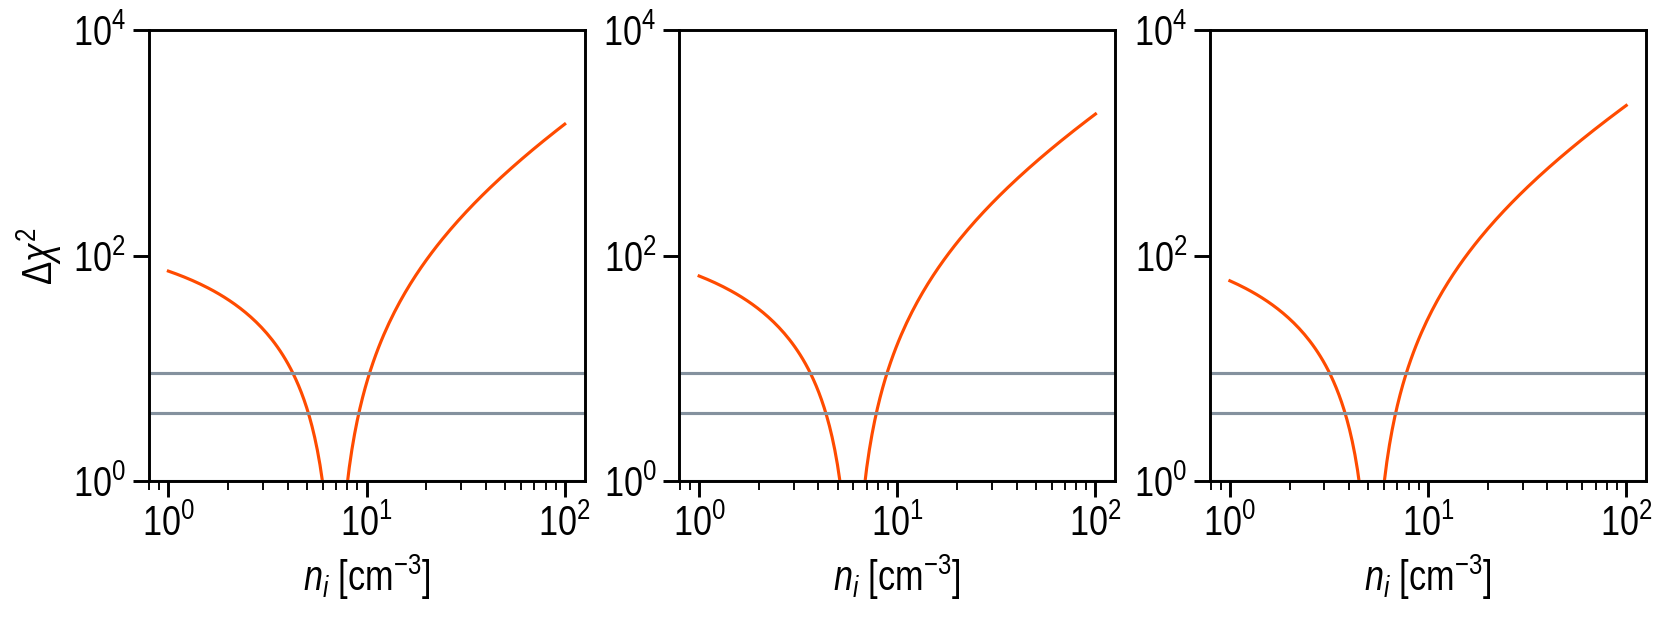

In [8]:
# 横軸 ni
fig, ax = plt.subplots(1, 3, figsize=(11, 4), dpi=150, layout='constrained')
for i in range(3):
    x_value = ni_1d[::3]
    y_value = chi2_3d[:, i, 0].T-np.min(chi2_3d[:, i, 0])

    ax[i].set_xlabel(r'$n_i$ [cm$^{-3}$]')
    ax[0].set_ylabel(r'$\Delta \chi^2$')
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')

    ax[i].set_ylim(1, 10000)

    ax[i].plot(x_value, y_value)

    ax[i].axhline(y=1.00, color=UC.gray)
    ax[i].axhline(y=4.00, color=UC.gray)
    ax[i].axhline(y=9.00, color=UC.gray)

    print(x_value[np.where(y_value <= 9.00)])

フィッティングパラメータが1つのとき、$\Delta \chi^2$の等高線はどこに引くべき？

| $p$ | $\nu = 1$ | $\nu = 2$ | $\nu = 3$ |
| ---- | ---- | ---- | ---- |
| 68.3% | 1.00 | 2.30 | 3.53 |
| 90% | 2.71 | 4.61 | 6.25 |
| 95.4% | 4.00 | 6.17 | 8.02 |
| 99% | 6.63 | 9.21 | 11.3 |
| 99.73% | 9.00 | 11.9 | 14.2 |
| 99.99% | 15.1 | 18.4 | 21.1 |


Lead angle best fit

In [9]:
# 磁場モデルの設定
mu_i_default = 139.6    # default: 139.6 [nT]
d_rj_default = 3.6      # default: 3.6 [RJ]
jm.Con2020.Config(mu_i=mu_i_default*0.8,
                  d=d_rj_default,
                  equation_type='analytic')

{'mu_i': 111.68,
 'i_rho': 16.7,
 'r0': 7.8,
 'r1': 51.4,
 'd': 3.6,
 'xt': 9.3,
 'xp': 155.8,
 'Edwards': True,
 'error_check': True,
 'CartesianIn': True,
 'CartesianOut': True,
 'equation_type': 'analytic',
 'Smooth': False,
 'DeltaRho': 1.0,
 'DeltaZ': 0.1,
 'g': 417659.3836476442,
 'azfunc': 'connerney',
 'wO_open': 0.1,
 'wO_om': 0.35,
 'thetamm': 16.1,
 'dthetamm': 0.5,
 'thetaoc': 10.716,
 'dthetaoc': 0.125}

In [10]:
# Moon position when the Alfven waves launched (Time: t0-tau_A)
r_A0_arr = r_moon*np.ones(56)
S3wlon_A0_arr = np.linspace(-50, 370, r_A0_arr.size)
Ai_best = Ai_3d[min_idx][0]
ni_best = ni_3d[min_idx][0]
Hp_best = H_3d[min_idx][0]

eqlead_best_MAW_N = np.zeros(r_A0_arr.size)
eqlead_best_MAW_S = np.zeros(r_A0_arr.size)
eqlead_best_TEB_N = np.zeros(r_A0_arr.size)
eqlead_best_TEB_S = np.zeros(r_A0_arr.size)
TEB_dt_arr = np.zeros(r_A0_arr.size)

current_coef, _ = read_current_coef()
D_coef, _ = read_disk_thick_coef()
D_disk = 3.6*RJ               # [m]
Hp = (2/np.pi)*D_disk*D_coef  # [m]
for i in range(r_A0_arr.size):
    r_A0 = r_A0_arr[i]
    S3wlon_A0 = S3wlon_A0_arr[i]
    S_A0 = Wave.Awave().tracefield(r_A0,
                                   np.radians(S3wlon_A0),
                                   1
                                   )
    tau, _, _, _ = Wave.Awave().trace3_magnetodisk(
        r_A0,
        np.radians(S3wlon_A0),
        0,
        S_A0,
        Ai_best,
        ni_best,
        Hp,
        -1,
        current_coef=current_coef,
        thickness_coef=D_coef,
    )

    eqlead_best_MAW_N[i] = tau*360/Psyn     # [deg]
    TEB_dt_arr[i] = TEB_transit(r_A0, S3wlon_A0, TARGET_MOON)
    eqlead_best_TEB_S[i] = (tau+TEB_dt_arr[i])*360/Psyn     # [deg]

    tau, _, _, _ = Wave.Awave().trace3_magnetodisk(
        r_A0,
        np.radians(S3wlon_A0),
        0,
        S_A0,
        Ai_best,
        ni_best,
        Hp,
        1,
        current_coef=current_coef,
        thickness_coef=D_coef,
    )

    eqlead_best_MAW_S[i] = tau*360/Psyn     # [deg]
    eqlead_best_TEB_N[i] = (tau+TEB_dt_arr[i])*360/Psyn     # [deg]

/tmp/ipykernel_1645925/3200185356.py:14: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  select_pj = np.where(con20_pj_idx == PJ_num[0])
/tmp/ipykernel_1645925/3200185356.py:31: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  select_pj = np.where(con20_pj_idx == PJ_num[0])


Tracing field line 1 of 1 (100.00)%


ArgumentError: argument 1: <class 'TypeError'>: wrong type